## Step 1. Import Libraries

Import các thư viện cần thiết cho quá trình phân cụm và trực quan hóa dữ liệu:

- Pandas: xử lý dữ liệu
- NumPy: tính toán số học
- Matplotlib: trực quan hóa kết quả

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Step 2. Load Dataset

Đọc tập dữ liệu đã được tiền xử lý từ file `customer_personality_preprocessed.csv` và chuyển đổi thành ma trận đặc trưng phục vụ thuật toán DBSCAN.

Hiển thị danh sách các thuộc tính được sử dụng trong quá trình phân cụm khách hàng.

In [2]:
df = pd.read_csv("customer_personality_preprocessed.csv")

X = df.values
print(df.columns.tolist())

['Education', 'Marital_Status', 'Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'DaysCustomer', 'Age', 'children']


## Step 4. Euclidean Distance

Xây dựng hàm tính khoảng cách Euclidean giữa hai điểm dữ liệu. Khoảng cách này được sử dụng để xác định mức độ tương đồng giữa các khách hàng.

In [3]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

## Step 5. Neighborhood Search

Xây dựng hàm tìm kiếm các điểm lân cận nằm trong bán kính `eps` của một điểm dữ liệu. Đây là bước quan trọng để xác định Core Point trong DBSCAN.

In [4]:
def region_query(X, point_idx, eps):

    neighbors = []

    for i in range(len(X)):

        distance = euclidean_distance(
            X[point_idx],
            X[i]
        )

        if distance <= eps:
            neighbors.append(i)

    return neighbors

## Step 6. K-Distance Analysis (k = 15)

Tính khoảng cách tới láng giềng gần nhất thứ 15 của mỗi điểm dữ liệu và xây dựng K-Distance Graph để hỗ trợ lựa chọn giá trị `eps`.

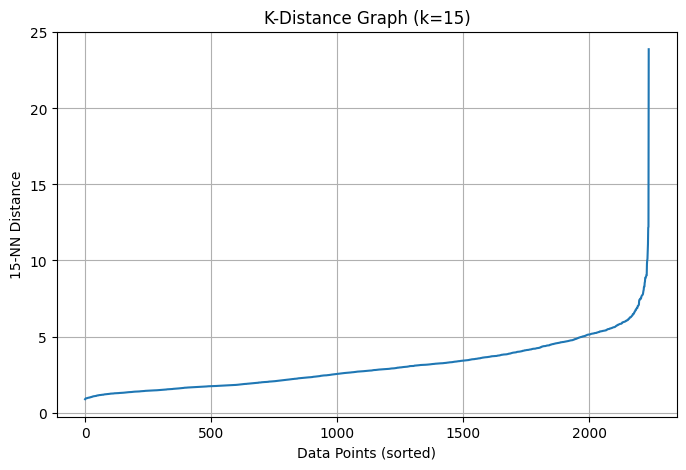

In [5]:
# K-Distance Graph tự cài đặt

k = 15  # thường chọn bằng min_samples

k_distances = []

for i in range(len(X)):

    distances = []

    for j in range(len(X)):

        if i != j:

            d = euclidean_distance(
                X[i],
                X[j]
            )

            distances.append(d)

    distances.sort()

    # khoảng cách tới láng giềng thứ k
    k_distances.append(
        distances[k - 1]
    )

k_distances.sort()

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel(f"{k}-NN Distance")
plt.title(f"K-Distance Graph (k={k})")
plt.grid(True)
plt.show()

## K-Distance Analysis (k = 20)

Lặp lại quá trình phân tích K-Distance với `k = 20` để kiểm tra tính ổn định của giá trị `eps`.

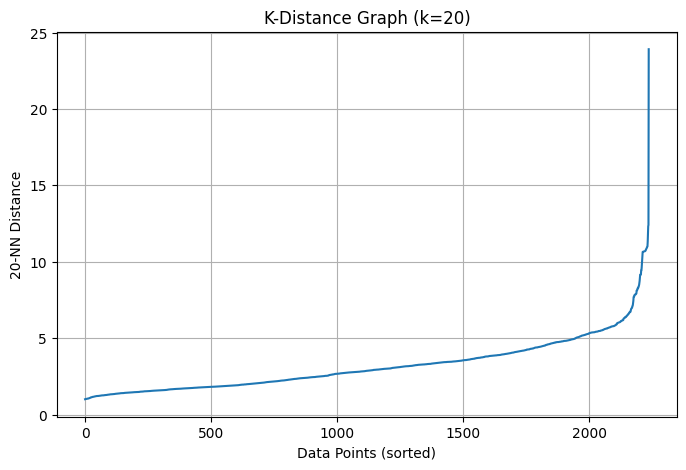

In [6]:
# K-Distance Graph tự cài đặt

k = 20  # thường chọn bằng min_samples

k_distances = []

for i in range(len(X)):

    distances = []

    for j in range(len(X)):

        if i != j:

            d = euclidean_distance(
                X[i],
                X[j]
            )

            distances.append(d)

    distances.sort()

    # khoảng cách tới láng giềng thứ k
    k_distances.append(
        distances[k - 1]
    )

k_distances.sort()

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel(f"{k}-NN Distance")
plt.title(f"K-Distance Graph (k={k})")
plt.grid(True)
plt.show()

### Nhận xét

Đối với cả hai giá trị `k = 15` và `k = 20`, đồ thị K-Distance đều xuất hiện điểm gãy (elbow point) tại vùng khoảng cách xấp xỉ 6. Điều này cho thấy giá trị `eps ≈ 6` là một ứng viên phù hợp cho thuật toán DBSCAN.

So với `k = 20`, đồ thị với `k = 15` thể hiện điểm gãy rõ ràng hơn, giúp việc xác định giá trị `eps` trực quan hơn. Do đó, các giá trị `eps` quanh 6 cùng với `min_samples = 15` và `20` được lựa chọn để tiếp tục đánh giá trong bước Hyperparameter Tuning.

## Step 7. DBSCAN Implementation

Cài đặt thuật toán DBSCAN từ đầu (Scratch Implementation), bao gồm:

- Tìm Core Point
- Mở rộng cụm
- Gán nhãn cụm
- Xác định điểm nhiễu (Noise)

In [7]:
class DBSCAN:

    def __init__(
        self,
        eps=2.0,
        min_samples=20
    ):

        self.eps = eps
        self.min_samples = min_samples
    def fit(self, X):

        n = len(X)

        # -1 = noise / chưa thuộc cluster nào
        labels = np.full(n, -1)

        # đánh dấu điểm đã duyệt
        visited = np.zeros(n, dtype=bool)

        cluster_id = 0

        for point_idx in range(n):

            if visited[point_idx]:
                continue

            visited[point_idx] = True

            neighbors = region_query(
                X,
                point_idx,
                self.eps
            )

            # Không đủ láng giềng -> noise
            if len(neighbors) < self.min_samples:

                labels[point_idx] = -1

            else:

                self.expand_cluster(
                    X,
                    labels,
                    visited,
                    point_idx,
                    neighbors,
                    cluster_id
                )

                cluster_id += 1

        self.labels_ = labels

        return self

    def expand_cluster(
        self,
        X,
        labels,
        visited,
        point_idx,
        neighbors,
        cluster_id
    ):
        """
        Mở rộng cluster từ một Core Point
        """

        labels[point_idx] = cluster_id

        i = 0

        while i < len(neighbors):

            neighbor_idx = neighbors[i]

            if not visited[neighbor_idx]:

                visited[neighbor_idx] = True

                new_neighbors = region_query(
                    X,
                    neighbor_idx,
                    self.eps
                )

                # Nếu hàng xóm cũng là Core Point
                if len(new_neighbors) >= self.min_samples:

                    neighbors.extend(new_neighbors)

            # Nếu chưa thuộc cluster nào
            if labels[neighbor_idx] == -1:

                labels[neighbor_idx] = cluster_id

            i += 1

    def fit_predict(self, X):

        self.fit(X)

        return self.labels_

## Step 8. Cluster Evaluation Metric

Xây dựng hàm tính Silhouette Score để đánh giá chất lượng phân cụm dựa trên mức độ gắn kết trong cụm và tách biệt giữa các cụm.

In [8]:
def silhouette_score_custom(X, labels):

    unique_clusters = np.unique(labels)
    unique_clusters = unique_clusters[
        unique_clusters != -1
    ]

    scores = []

    for i in range(len(X)):

        if labels[i] == -1:
            continue

        same_cluster_idx = np.where(
            labels == labels[i]
        )[0]

        if len(same_cluster_idx) <= 1:
            continue

        a_distances = []

        for idx in same_cluster_idx:

            if idx != i:

                a_distances.append(
                    euclidean_distance(
                        X[i],
                        X[idx]
                    )
                )

        a = np.mean(a_distances)

        b = np.inf

        for cluster in unique_clusters:

            if cluster == labels[i]:
                continue

            other_cluster_idx = np.where(
                labels == cluster
            )[0]

            distances = []

            for idx in other_cluster_idx:

                distances.append(
                    euclidean_distance(
                        X[i],
                        X[idx]
                    )
                )

            b = min(
                b,
                np.mean(distances)
            )

        s = (b - a) / max(a, b)

        scores.append(s)

    if len(scores) == 0:
        return np.nan

    return np.mean(scores)

## Step 9. Hyperparameter Tuning

Thử nghiệm nhiều tổ hợp giá trị:

- eps
- min_samples

Đối với mỗi tổ hợp, thực hiện phân cụm và đánh giá bằng:

- Number of Clusters
- Number of Noise Points
- Noise Percentage
- Silhouette Score

In [9]:
eps_values = [4.0, 5.0, 6.0]
min_samples_values = [15, 20, 25]

results = []

for eps in eps_values:

    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X)

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        n_noise = np.sum(labels == -1)

        noise_percent = (
            n_noise / len(labels)
        ) * 100

        silhouette = np.nan

        # Silhouette chỉ tính được khi >= 2 cluster
        if n_clusters >= 2:

            try:
                silhouette = silhouette_score_custom( # type: ignore
                    X,
                    labels
                )

            except:
                silhouette = np.nan

        results.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            round(noise_percent, 2),
            round(silhouette, 4)
            if not np.isnan(silhouette)
            else np.nan
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "clusters",
        "noise_points",
        "noise_percent",
        "silhouette"
    ]
)

results_df = results_df.sort_values(
    by="silhouette",
    ascending=False
).reset_index(drop=True)
print(results_df)

   eps  min_samples  clusters  noise_points  noise_percent  silhouette
0  6.0           15         2            46           2.06      0.5007
1  4.0           15         1           354          15.82         NaN
2  4.0           20         1           373          16.67         NaN
3  4.0           25         1           376          16.81         NaN
4  5.0           15         1           136           6.08         NaN
5  5.0           20         1           140           6.26         NaN
6  5.0           25         1           149           6.66         NaN
7  6.0           20         1            66           2.95         NaN
8  6.0           25         1            68           3.04         NaN


### Nhận xét

Bảng kết quả cho thấy tổ hợp tham số **eps = 6.0** và **min_samples = 15** mang lại kết quả phân cụm tốt nhất. Với bộ tham số này, thuật toán DBSCAN tạo được **2 cụm**, chỉ có **46 điểm nhiễu (2,06%)** và đạt **Silhouette Score = 0,5007**, cho thấy các cụm có mức độ tách biệt và gắn kết tương đối tốt.

Đối với các giá trị **eps = 4.0** và **eps = 5.0**, thuật toán chỉ tạo được **1 cụm duy nhất**, đồng thời số lượng điểm nhiễu khá lớn, dao động từ khoảng **6% đến 17%** tổng dữ liệu. Điều này cho thấy bán kính lân cận còn quá nhỏ, khiến nhiều điểm dữ liệu không đủ điều kiện tham gia vào cụm và bị xem là nhiễu.

Khi tăng **eps lên 6.0**, số lượng điểm nhiễu giảm đáng kể và xuất hiện thêm một cụm mới, chứng tỏ thuật toán đã nhận diện được cấu trúc dữ liệu tốt hơn. Tuy nhiên, nếu tiếp tục tăng **min_samples** từ 15 lên 20 và 25, số cụm lại giảm xuống còn 1, cho thấy điều kiện hình thành Core Point trở nên quá chặt chẽ, làm giảm khả năng phát hiện các cụm nhỏ trong dữ liệu.

Nhìn chung, kết quả cho thấy bộ tham số **eps = 6.0** và **min_samples = 15** là lựa chọn phù hợp nhất cho tập dữ liệu này vì vừa hạn chế được số lượng điểm nhiễu, vừa tạo ra nhiều hơn một cụm và đạt chất lượng phân cụm cao nhất theo chỉ số Silhouette Score.

## Step 10. Final DBSCAN Model

Huấn luyện mô hình DBSCAN với bộ tham số tốt nhất được lựa chọn từ bước đánh giá trước đó.

In [26]:
model = DBSCAN(
    eps=6.0,
    min_samples=15
)

labels = model.fit_predict(X)

print(labels[:50])

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0
  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]


In [25]:
print(np.unique(labels))

[-1  0  1]


### Nhận xét

Kết quả gán nhãn cho thấy DBSCAN đã phân chia dữ liệu thành hai cụm chính (Cluster 0 và Cluster 1), đồng thời xác định được một số điểm nhiễu mang nhãn `-1`.

Trong phần nhãn hiển thị, phần lớn các quan sát thuộc Cluster 0, trong khi một số ít điểm được đánh dấu là nhiễu. Điều này cho thấy dữ liệu có tồn tại các vùng mật độ cao hình thành cụm và một số quan sát nằm tách biệt khỏi cấu trúc chung của dữ liệu.

Khả năng nhận diện các điểm nhiễu là một ưu điểm quan trọng của DBSCAN, giúp mô hình phát hiện các quan sát bất thường mà không cần ép chúng vào bất kỳ cụm nào.

## Step 11. Cluster Assignment

Sinh nhãn phân cụm cho từng khách hàng trong tập dữ liệu.

In [11]:
# số lượng cụm
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 2


## Step 12. Final Silhouette Score

Tính Silhouette Score cho mô hình DBSCAN cuối cùng.

Chỉ số này được sử dụng để đánh giá tổng thể chất lượng phân cụm sau khi lựa chọn tham số tối ưu.

In [12]:
# 13. Silhouette Score cuối

score = silhouette_score_custom(
    X,
    labels
)

print(score)

0.5006627843500674


## Step 13. Cluster Distribution

Thống kê số lượng khách hàng trong từng cụm.

Bước này giúp đánh giá mức độ cân bằng giữa các cụm và xác định tỷ lệ khách hàng bị phân loại là nhiễu.

In [13]:
# Số lượng điểm trong mỗi cụm
pd.Series(labels).value_counts().sort_index()

-1      46
 0    2173
 1      18
Name: count, dtype: int64

## Step 14. Cluster Profiling

Phân tích đặc trưng trung bình của từng cụm khách hàng.

Các giá trị trung bình của từng thuộc tính được tính toán theo từng cụm nhằm:

- Hiểu hành vi khách hàng.
- Xác định các phân khúc khách hàng khác nhau.
- Hỗ trợ đưa ra các chiến lược marketing phù hợp cho từng nhóm.

In [14]:
df_cluster = df.copy()
df_cluster["Cluster"] = labels

df_cluster.groupby("Cluster").mean()

,Education,Marital_Status,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,DaysCustomer,Age,children
Cluster,,,,,,,,,,,,,,,,,,,,,
-1,0.082407,-0.075998,1.130123,0.947428,-0.15080,0.873072,-0.144878,0.279519,0.616317,0.494611,...,0.556049,1.618324,1.314244,0.977840,5.553209,0.366912,0.923014,0.075368,-0.162633,-0.512868
0,0.001803,0.000273,-0.021208,-0.016436,0.00326,-0.015733,0.004637,-0.003328,-0.008781,-0.010737,...,-0.009449,-0.031905,-0.025507,-0.018527,-0.116590,-0.094980,-0.017360,-0.003674,0.001664,0.007867
1,-0.428291,0.161260,-0.327794,-0.437003,-0.00821,-0.331816,-0.189581,-0.312517,-0.515001,0.032141,...,-0.280343,-0.284036,-0.279414,-0.262299,-0.116590,10.528533,-0.263058,0.250923,0.214779,0.360961


### Nhận xét

Kết quả phân tích đặc trưng trung bình của các cụm cho thấy sự khác biệt rõ rệt giữa các nhóm khách hàng.

- **Cluster 0** có giá trị trung bình của hầu hết các thuộc tính gần bằng 0, cho thấy đây là nhóm khách hàng đại diện cho phần lớn tập dữ liệu với các đặc điểm và hành vi mua sắm ở mức trung bình. Nhóm này không có sự nổi bật rõ rệt ở bất kỳ thuộc tính nào và được xem là phân khúc khách hàng phổ biến nhất.

- **Cluster 1** có xu hướng chi tiêu thấp hơn mức trung bình ở nhiều danh mục sản phẩm như rượu vang, thịt, cá, sản phẩm ngọt và vàng. Thu nhập của nhóm này cũng thấp hơn trung bình. Tuy nhiên, nhóm khách hàng này có tỷ lệ khiếu nại (Complain) và thời gian gắn bó với doanh nghiệp cao hơn mức trung bình, cho thấy đây là nhóm khách hàng có hành vi khác biệt so với đa số khách hàng trong tập dữ liệu.

- **Cluster -1 (Noise)** bao gồm các khách hàng ngoại lệ được DBSCAN xác định là không thuộc cụm nào. Nhóm này có thu nhập và mức chi tiêu cho nhiều loại sản phẩm cao hơn đáng kể so với trung bình, đồng thời có tỷ lệ tham gia các chiến dịch marketing (AcceptedCmp1–AcceptedCmp5) cao hơn các nhóm còn lại. Điều này cho thấy các điểm nhiễu chủ yếu là những khách hàng có hành vi mua sắm đặc biệt và khác biệt đáng kể so với phần lớn khách hàng.

Nhìn chung, kết quả phân cụm cho thấy tập khách hàng chủ yếu tập trung ở một phân khúc trung bình, trong khi các khách hàng có hành vi tiêu dùng đặc biệt hoặc khác biệt được tách thành các nhóm nhỏ hoặc được nhận diện là các điểm ngoại lệ.

## Step 15. Cluster and Noise Analysis

### Mục đích

Bước này được thực hiện nhằm đánh giá kết quả phân cụm của thuật toán DBSCAN thông qua số lượng cụm được tạo ra và số điểm nhiễu được phát hiện.

Các điểm mang nhãn `-1` được xem là nhiễu (*noise points*), tức là các quan sát không thuộc về bất kỳ cụm nào do nằm trong vùng mật độ thấp. Tỷ lệ nhiễu được tính để đánh giá mức độ phù hợp của bộ tham số đã lựa chọn.

In [24]:
noise_count = np.sum(labels == -1)
noise_percent = noise_count / len(labels) * 100

print("Number of Clusters:",
      len(set(labels)) - (1 if -1 in labels else 0))

print("Noise Points:", noise_count)

print(f"Noise Percentage: {noise_percent:.2f}%")

Number of Clusters: 2
Noise Points: 46
Noise Percentage: 2.06%


### Nhận xét

Mô hình DBSCAN tạo ra 2 cụm khách hàng chính và xác định được 46 điểm nhiễu, chiếm 2.06% tổng số quan sát.

Tỷ lệ nhiễu thấp cho thấy phần lớn dữ liệu được gán vào các cụm có mật độ đủ cao. Đồng thời, DBSCAN vẫn phát hiện được một số điểm bất thường không thuộc về bất kỳ cụm nào, giúp tăng khả năng nhận diện outlier.

Với tỷ lệ nhiễu thấp và Silhouette Score đạt 0.5007, mô hình cho thấy khả năng phân cụm tương đối tốt trên tập dữ liệu khách hàng.

## Step 16. PCA Visualization

Do dữ liệu khách hàng bao gồm nhiều thuộc tính nên không thể trực quan hóa trực tiếp trên mặt phẳng 2 chiều. Vì vậy, kỹ thuật PCA (Principal Component Analysis) được sử dụng để giảm số chiều dữ liệu xuống còn 2 thành phần chính nhưng vẫn giữ lại phần lớn thông tin quan trọng.

Biểu đồ giúp quan sát trực quan sự phân bố của các cụm khách hàng được tạo bởi thuật toán DBSCAN trong không gian đặc trưng tổng quát.

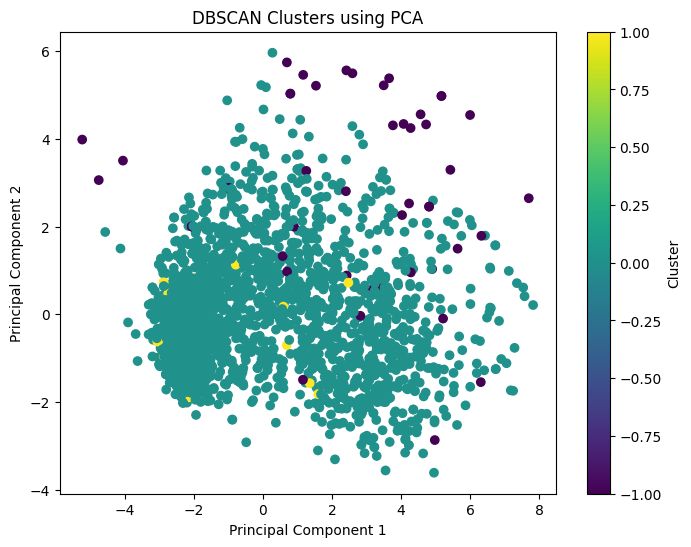

In [15]:
from sklearn.decomposition import PCA

# Giảm chiều dữ liệu về 2 chiều
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters using PCA")
plt.colorbar(label="Cluster")
plt.show()

### Nhận xét

Biểu đồ PCA cho thấy dữ liệu khách hàng phân bố tập trung chủ yếu tại vùng trung tâm và không xuất hiện nhiều nhóm tách biệt rõ ràng trong không gian hai chiều. Các điểm dữ liệu có xu hướng liên kết chặt chẽ với nhau, trong khi một số điểm nằm rải rác ở xa vùng mật độ cao thể hiện các quan sát có đặc điểm khác biệt hơn so với phần lớn dữ liệu. Nhìn chung, cấu trúc dữ liệu thể hiện mức độ tương đồng khá cao giữa các khách hàng và chỉ tồn tại một số nhóm nhỏ hoặc điểm dữ liệu nằm tách biệt khỏi khu vực tập trung chính.

## Step 17. Cluster Size Distribution

Thống kê số lượng khách hàng trong từng cụm sau khi thực hiện phân cụm bằng DBSCAN.

Biểu đồ giúp đánh giá sự phân bố dữ liệu giữa các cụm và xác định tỷ lệ khách hàng bị phân loại là nhiễu.

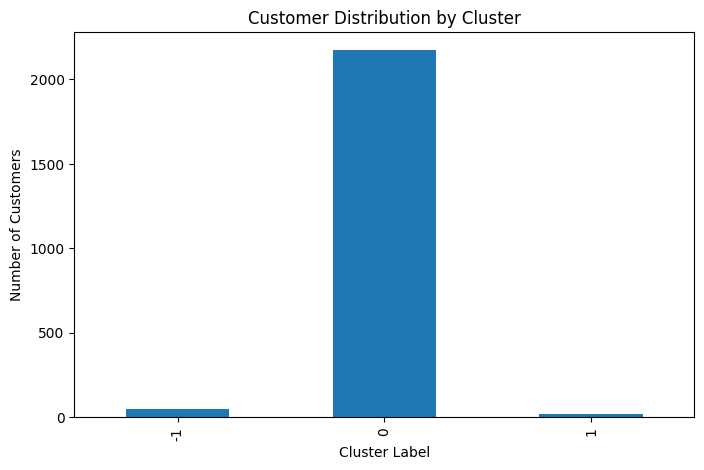

-1      46
 0    2173
 1      18
Name: count, dtype: int64


In [16]:
cluster_counts = (
    pd.Series(labels)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Cluster Label")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Cluster")

plt.show()

print(cluster_counts)

### Nhận xét

Biểu đồ cho thấy DBSCAN đã tạo ra một cụm chính (Cluster 0) với 2.173 khách hàng, chiếm khoảng 97,14% tổng số quan sát. Điều này cho thấy phần lớn khách hàng trong tập dữ liệu có đặc điểm tương đồng và tập trung trong cùng một vùng mật độ dữ liệu.

Bên cạnh đó, thuật toán phát hiện một cụm nhỏ (Cluster 1) gồm 18 khách hàng, chiếm khoảng 0,80% tổng dữ liệu. Nhóm khách hàng này có những đặc trưng khác biệt so với phần lớn khách hàng còn lại và có thể được xem là một phân khúc khách hàng đặc biệt.

Ngoài ra, có 46 khách hàng (2,06%) được xác định là điểm nhiễu (Noise), tức là các khách hàng không thuộc bất kỳ cụm nào do nằm tách biệt khỏi các vùng mật độ cao. Tỷ lệ nhiễu tương đối thấp cho thấy dữ liệu khá ổn định và không chứa nhiều trường hợp ngoại lệ.

Nhìn chung, kết quả cho thấy dữ liệu khách hàng chủ yếu tập trung vào một phân khúc lớn, trong khi chỉ có một số ít khách hàng mang đặc điểm khác biệt hoặc bất thường. Điều này phản ánh rằng hành vi và đặc điểm của khách hàng trong tập dữ liệu tương đối đồng nhất, dẫn đến việc DBSCAN không hình thành nhiều cụm riêng biệt.